# Experimento A — recuperación de la corrida paper 4×4

**TTAP: 4 helicópteros, 4 áreas de demanda y 20–60 tareas**

Este notebook **no vuelve a ejecutar las heurísticas ni HiGHS**. Recupera la corrida paper completada del Experimento A (`20260808_112401-0400`) desde sus archivos CSV y genera las mismas figuras y auditorías gráficas utilizadas en el notebook recuperado del Experimento B.

La recuperación conserva:

- 30 semillas para cada tamaño de 20, 30, 40, 50 y 60 tareas;
- presupuestos HiGHS de 1, 5, 15, 60 y 600 segundos;
- separación entre incumbent, plan positivo y óptimo certificado;
- figuras A1, A2, A3, A5, A6, A7 y A8;
- exportación de cada figura como PNG de 2000 dpi y PDF vectorial;
- selección reproducible de una instancia certificada representativa para A6 y A7.

Los archivos recuperados se leen desde `ttap_experiment_A_4x4_impact_anytime_traced/`. Las figuras nuevas se guardan en una carpeta terminada en `_recovered`, por lo que no sobrescriben los resultados originales.


In [1]:
# ============================================================
# 01. IMPORTS, ENVIRONMENT AND GLOBAL CONFIGURATION
# ============================================================

import math
import os
import platform
import sys
import time
from collections import Counter, defaultdict, deque
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import coo_matrix

try:
    import psutil
except ImportError:
    psutil = None

if not hasattr(scipy.optimize, "milp"):
    raise RuntimeError("This notebook requires scipy.optimize.milp (SciPy >= 1.9).")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# -----------------------------
# Execution mode
# -----------------------------
RUN_MODE = "paper"  # "quick" or "paper"

if RUN_MODE == "quick":
    ACTIVE_TASK_COUNTS = [20]
    ACTIVE_SEEDS = [1]
    ACTIVE_HIGHS_BUDGETS = [1, 5, 15, 60, 600]
elif RUN_MODE == "paper":
    ACTIVE_TASK_COUNTS = [20, 30, 40, 50, 60]
    ACTIVE_SEEDS = list(range(1, 31))
    ACTIVE_HIGHS_BUDGETS = [1, 5, 15, 60, 600]
else:
    raise ValueError("RUN_MODE must be 'quick' or 'paper'.")

TASK_COUNTS = [20, 30, 40, 50, 60]
INSTANCE_SEEDS = list(range(1, 31))
MAX_TASKS = max(TASK_COUNTS)

TASK_GENERATOR_VERSION = "matched_v3_impact_anytime"
TASK_PROFILE_STREAM_ID = 21001
TASK_LOCATION_STREAM_A_ID = 22001

TASK_CLASS_NAMES = np.array(["medical", "personnel", "cargo"])
TASK_CLASS_PROBABILITIES = np.array([0.45, 0.30, 0.25])
VISUAL_REQUIRED_PROBABILITY = 0.40

DEFAULT_PARAMS = {
    "SERVICE_TIME": 6.0,
    "RECOVERY_TIME": 2.0,
    "TMAX": 200.0,
    "ALPHA": 0.1,
    "TIME_UNIT": 1.0,
    "USE_PRIORITY_WEIGHTS": True,
    "PRIORITY_WEIGHTS": {
        "medical": 2.0,
        "personnel": 1.5,
        "cargo": 1.0,
    },
    # Fixed class-specific references used both to make q_i dimensionless
    # and to establish the relative scale between task classes.
    "IMPACT_REFERENCES": {
        "medical": 3.0,      # medical evacuees
        "personnel": 3.0,    # transported people
        "cargo": 500.0,      # kg delivered
    },
}

EXECUTION_TIMEZONE = ZoneInfo("America/Santiago")
EXECUTION_ID = datetime.now(EXECUTION_TIMEZONE).strftime("%Y%m%d_%H%M%S%z")
RUN_PREFIX = f"A4x4_{RUN_MODE}_{EXECUTION_ID}"
OUTPUT_DIR = Path("ttap_experiment_A_4x4_impact_anytime_traced")
FIGURES_DIR = OUTPUT_DIR / "figures" / RUN_PREFIX
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HIGHS_BENCHMARK_BUDGET = max(ACTIVE_HIGHS_BUDGETS)
HIGHS_METHOD = f"HiGHS-{HIGHS_BENCHMARK_BUDGET:g}s"

METHOD_ORDER = [
    "Greedy-Benefit",
    "Greedy-Density-Operational",
    HIGHS_METHOD,
]

METHOD_LABELS = {
    "Greedy-Benefit": "Greedy-Benefit",
    "Greedy-Density-Operational": "Greedy-Density",
    HIGHS_METHOD: f"HiGHS ({HIGHS_BENCHMARK_BUDGET:g} s)",
}

METHOD_COLORS = {
    "Greedy-Benefit": "#6C757D",
    "Greedy-Density-Operational": "#2A9D8F",
    HIGHS_METHOD: "#264653",
}


def save_current_figure(name, dpi=220):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figure saved at:", path)


memory_gb = psutil.virtual_memory().total / (1024 ** 3) if psutil is not None else np.nan
print("Computational environment")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print(f"RAM: {memory_gb:.2f} GB" if np.isfinite(memory_gb) else "RAM: not reported (optional psutil package unavailable)")
print("RUN_MODE:", RUN_MODE)
print("EXECUTION_ID:", EXECUTION_ID)
print("Task counts:", ACTIVE_TASK_COUNTS)
print("Seeds:", ACTIVE_SEEDS)
print("HiGHS budgets:", ACTIVE_HIGHS_BUDGETS)

Computational environment
Python: 3.11.3
Platform: macOS-26.6.2-arm64-arm-64bit
Processor: arm
NumPy: 2.4.6
Pandas: 3.0.5
SciPy: 1.17.1
Matplotlib: 3.11.1
RAM: 8.00 GB
RUN_MODE: paper
EXECUTION_ID: 20260828_182025-0400
Task counts: [20, 30, 40, 50, 60]
Seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
HiGHS budgets: [1, 5, 15, 60, 600]


In [2]:
# ============================================================
# 03. SCENARIO GENERATION AND IMPACT METADATA
# ============================================================

def default_nodes():
    return {
        "Base": (0.0, 0.0),
        "A": (10.0, 5.0),
        "B": (20.0, 15.0),
        "C": (30.0, 10.0),
        "D": (40.0, 20.0),
    }


def default_fleet():
    return {
        "H1": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 150},
        "H2": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 120},
        "H3": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 140},
        "H4": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 160},
    }


def classify_task_priority(task):
    if task["med"] > 0:
        return "medical"
    if task["pers"] > 0:
        return "personnel"
    if task["load"] > 0:
        return "cargo"
    raise ValueError("Task has no positive operational requirement.")


def raw_humanitarian_impact(task, task_class):
    """Physical output used to define q_i; not a resource-cost score."""
    if task_class == "medical":
        return float(task["med"]), "medical evacuees"
    if task_class == "personnel":
        return float(task["pers"]), "people transported"
    if task_class == "cargo":
        return float(task["load"]), "kg delivered"
    raise ValueError(f"Unknown task class: {task_class}")


def assign_task_value_metadata(scenario):
    params = scenario["params"]
    weights = params["PRIORITY_WEIGHTS"]
    references = params["IMPACT_REFERENCES"]
    use_weights = params["USE_PRIORITY_WEIGHTS"]

    for task in scenario["tasks"].values():
        task_class = classify_task_priority(task)
        raw_impact, impact_unit = raw_humanitarian_impact(task, task_class)
        reference = float(references[task_class])
        if reference <= 0:
            raise ValueError("Every impact reference must be positive.")

        task["priority_class"] = task_class
        task["class_weight"] = float(weights[task_class]) if use_weights else 1.0
        task["raw_impact"] = raw_impact
        task["impact_unit"] = impact_unit
        task["impact_reference"] = reference
        task["impact"] = raw_impact / reference
        task["potential_value"] = task["class_weight"] * task["impact"]

    total_potential_value = sum(
        task["potential_value"] for task in scenario["tasks"].values()
    )
    if total_potential_value <= 0:
        raise ValueError("Total potential mission value must be positive.")

    scenario["total_potential_value"] = float(total_potential_value)
    return scenario


def make_reproducible_rng(seed, stream_id):
    return np.random.default_rng(
        np.random.SeedSequence([int(seed), int(stream_id)])
    )


REFERENCE_FLEET = {
    h: {k: v for k, v in data.items() if k != "speed"}
    for h, data in default_fleet().items()
}


def task_is_structurally_feasible(task, fleet=REFERENCE_FLEET):
    return any(
        (not task["visual"] or helo["visual"])
        and helo["load"] >= task["load"]
        and helo["med"] >= task["med"]
        and helo["pers"] >= task["pers"]
        for helo in fleet.values()
    )


def draw_task_profile(rng):
    task_class = str(rng.choice(TASK_CLASS_NAMES, p=TASK_CLASS_PROBABILITIES))
    visual = bool(rng.random() < VISUAL_REQUIRED_PROBABILITY)

    if task_class == "medical":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = int(rng.integers(1, 4))
        pers = int(rng.integers(0, 4))
    elif task_class == "personnel":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = 0
        pers = int(rng.integers(1, 4))
    else:
        load = int(rng.choice(np.arange(100, 501, 50)))
        med = 0
        pers = 0

    t_opt = int(rng.integers(8, 36))
    t_eff = t_opt + int(rng.integers(12, 27))
    t_ineff = t_eff + int(rng.integers(20, 61))

    task = {
        "visual": visual,
        "load": load,
        "med": med,
        "pers": pers,
        "t_opt": float(t_opt),
        "t_eff": float(t_eff),
        "t_ineff": float(t_ineff),
    }
    if classify_task_priority(task) != task_class:
        raise AssertionError("Generated class is inconsistent.")
    if not task_is_structurally_feasible(task):
        raise AssertionError("Generated task is structurally infeasible.")
    return task


def task_prefix_is_complex(tasks, n_tasks):
    prefix = [tasks[i] for i in range(1, n_tasks + 1)]
    class_counts = Counter(classify_task_priority(task) for task in prefix)
    minimum_class_count = max(3, int(math.floor(0.12 * n_tasks)))
    if any(class_counts[name] < minimum_class_count for name in TASK_CLASS_NAMES):
        return False

    visual_count = sum(task["visual"] for task in prefix)
    if not (math.ceil(0.25 * n_tasks) <= visual_count <= math.floor(0.60 * n_tasks)):
        return False

    resource_vectors = {
        (task["load"], task["med"], task["pers"]) for task in prefix
    }
    return len(resource_vectors) >= math.ceil(0.65 * n_tasks)


def generate_task_profiles(n_tasks=20, seed=1):
    if n_tasks not in TASK_COUNTS:
        raise ValueError(f"n_tasks must belong to {TASK_COUNTS}.")
    rng = make_reproducible_rng(seed, TASK_PROFILE_STREAM_ID)
    for _ in range(10000):
        candidate = {
            task_id: draw_task_profile(rng)
            for task_id in range(1, MAX_TASKS + 1)
        }
        if all(task_prefix_is_complex(candidate, n) for n in TASK_COUNTS):
            return {
                task_id: candidate[task_id].copy()
                for task_id in range(1, n_tasks + 1)
            }
    raise RuntimeError("Could not generate a sufficiently heterogeneous task set.")


def generate_asymmetric_locations(n_tasks, seed, node_choices):
    node_choices = list(node_choices)
    if len(node_choices) != 4:
        raise ValueError("Experiment A requires exactly four demand areas.")
    base_probabilities = np.array([0.45, 0.30, 0.17, 0.08])
    rng = make_reproducible_rng(seed, TASK_LOCATION_STREAM_A_ID)

    for _ in range(10000):
        hotspot_order = list(rng.permutation(node_choices))
        sequence = list(
            rng.choice(
                hotspot_order,
                size=MAX_TASKS,
                replace=True,
                p=base_probabilities,
            )
        )
        valid = True
        for prefix_size in TASK_COUNTS:
            counts = Counter(sequence[:prefix_size])
            values = np.array([counts[node] for node in node_choices])
            required_imbalance = max(4, int(math.ceil(0.20 * prefix_size)))
            if not np.all(values >= 1) or values.max() - values.min() < required_imbalance:
                valid = False
                break
        if valid:
            return {
                task_id: str(sequence[task_id - 1])
                for task_id in range(1, n_tasks + 1)
            }
    raise RuntimeError("Could not generate an asymmetric spatial allocation.")


def create_scenario(n_tasks=20, seed=1, scenario_id=None, params=None):
    if scenario_id is None:
        scenario_id = f"A4x4_T{n_tasks}_S{seed}"
    merged_params = DEFAULT_PARAMS.copy()
    merged_params["PRIORITY_WEIGHTS"] = DEFAULT_PARAMS["PRIORITY_WEIGHTS"].copy()
    merged_params["IMPACT_REFERENCES"] = DEFAULT_PARAMS["IMPACT_REFERENCES"].copy()
    if params:
        merged_params.update(params)

    nodes = default_nodes()
    tasks = generate_task_profiles(n_tasks=n_tasks, seed=seed)
    task_to_node = generate_asymmetric_locations(
        n_tasks=n_tasks,
        seed=seed,
        node_choices=[node for node in nodes if node != "Base"],
    )
    scenario = {
        "scenario_id": scenario_id,
        "experiment": "A",
        "task_generator_version": TASK_GENERATOR_VERSION,
        "seed": seed,
        "nodes": nodes,
        "helicopters": default_fleet(),
        "tasks": tasks,
        "task_to_node": task_to_node,
        "params": merged_params,
    }
    return assign_task_value_metadata(scenario)


def validate_scenario_structure(scenario):
    if len(scenario["helicopters"]) != 4:
        raise AssertionError("Experiment A must contain four helicopters.")
    if len([n for n in scenario["nodes"] if n != "Base"]) != 4:
        raise AssertionError("Experiment A must contain four demand areas.")
    for task_id, task in scenario["tasks"].items():
        if not task_is_structurally_feasible(task, scenario["helicopters"]):
            raise AssertionError(f"Task {task_id} is structurally infeasible.")
        if not (0 < task["impact"] <= 1):
            raise AssertionError(f"Task {task_id} has invalid normalized impact.")
        if not math.isclose(
            task["potential_value"],
            task["class_weight"] * task["impact"],
            rel_tol=0,
            abs_tol=1e-12,
        ):
            raise AssertionError(f"Task {task_id} has inconsistent value metadata.")
    return True


scenario_check = create_scenario(20, 1)
validate_scenario_structure(scenario_check)
print("Scenario generator and impact metadata validation passed.")


Scenario generator and impact metadata validation passed.


In [3]:
# ============================================================
# 04. COMMON FUNCTIONS AND TEMPORAL SATISFACTION
# ============================================================

def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        return int(h[1:]) if h.startswith("H") else int(h)
    return int(h)


def euclidean_distance(scenario, node_a, node_b):
    xa, ya = scenario["nodes"][node_a]
    xb, yb = scenario["nodes"][node_b]
    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(scenario, h, node_a, node_b):
    if node_a == node_b:
        return 0.0
    distance = euclidean_distance(scenario, node_a, node_b)
    return 60.0 * distance / scenario["helicopters"][h]["speed"]


def logistic_component(alpha, t, t_eff):
    return 1.0 / (1.0 + math.exp(alpha * (t - t_eff)))


def satisfaction(scenario, t, task):
    """Anchored function: S(t_opt)=1, S(t_eff)=0.5, S(t_ineff)=0."""
    alpha = float(scenario["params"]["ALPHA"])
    t_opt = float(task["t_opt"])
    t_eff = float(task["t_eff"])
    t_ineff = float(task["t_ineff"])
    if not (0 <= t_opt < t_eff < t_ineff):
        raise ValueError("Temporal thresholds must satisfy 0 <= t_opt < t_eff < t_ineff.")
    if alpha <= 0:
        raise ValueError("ALPHA must be positive.")
    if t <= t_opt:
        return 1.0
    if t >= t_ineff:
        return 0.0

    value_t = logistic_component(alpha, t, t_eff)
    if t <= t_eff:
        value_opt = logistic_component(alpha, t_opt, t_eff)
        value = 0.5 + 0.5 * (value_t - 0.5) / (value_opt - 0.5)
    else:
        value_ineff = logistic_component(alpha, t_ineff, t_eff)
        value = 0.5 * (value_t - value_ineff) / (0.5 - value_ineff)
    return float(np.clip(value, 0.0, 1.0))


def task_benefit(scenario, task_id, finish_time):
    task = scenario["tasks"][task_id]
    return (
        task["potential_value"]
        * satisfaction(scenario, finish_time, task)
        / scenario["total_potential_value"]
    )


def can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
    helo = scenario["helicopters"][h]
    task = scenario["tasks"][task_id]
    return (
        (not task["visual"] or helo["visual"])
        and load >= task["load"]
        and med >= task["med"]
        and pers >= task["pers"]
    )


def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def discretized_finish(start_time, duration, time_unit):
    k_now = int(round(start_time / time_unit))
    return time_from_step(k_now + ceil_steps(duration, time_unit), time_unit)


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(scenario, h):
    helo = scenario["helicopters"][h]
    return make_state("Base", 0, helo["load"], helo["med"], helo["pers"])


def sink_state():
    return ("SINK", -1, 0, 0, 0)


def validate_temporal_satisfaction(scenario):
    for task in scenario["tasks"].values():
        assert math.isclose(satisfaction(scenario, task["t_opt"], task), 1.0, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_eff"], task), 0.5, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_ineff"], task), 0.0, abs_tol=1e-12)
    return True


validate_temporal_satisfaction(scenario_check)
print("Temporal satisfaction validation passed.")


Temporal satisfaction validation passed.


## Recuperación de la corrida paper

Las siguientes celdas trabajan exclusivamente con los CSV ya generados.


In [4]:
# ============================================================
# RECOVERY — LOAD THE COMPLETED EXPERIMENT A PAPER RUN FROM CSV
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

ORIGINAL_EXECUTION_ID = "20260808_112401-0400"
ORIGINAL_RUN_PREFIX = (
    f"A4x4_paper_{ORIGINAL_EXECUTION_ID}"
)

OUTPUT_DIR = Path(
    "ttap_experiment_A_4x4_impact_anytime_traced"
)

FINAL_METRICS_PATH = OUTPUT_DIR / (
    "metrics_"
    f"{ORIGINAL_RUN_PREFIX}_"
    "matched_v3_impact_anytime.csv"
)

FINAL_LOGS_PATH = OUTPUT_DIR / (
    "task_logs_"
    f"{ORIGINAL_RUN_PREFIX}_"
    "matched_v3_impact_anytime.csv"
)

PARTIAL_METRICS_PATH = (
    OUTPUT_DIR
    / f"metrics_partial_{ORIGINAL_RUN_PREFIX}.csv"
)

PARTIAL_LOGS_PATH = (
    OUTPUT_DIR
    / f"task_logs_partial_{ORIGINAL_RUN_PREFIX}.csv"
)

TRACE_PATH = (
    OUTPUT_DIR
    / f"execution_trace_{ORIGINAL_RUN_PREFIX}.csv"
)

SUMMARY_PATH = (
    OUTPUT_DIR
    / f"experiment_summary_{ORIGINAL_RUN_PREFIX}.csv"
)

# Prefer final files; otherwise recover the last checkpoint.
metrics_path = (
    FINAL_METRICS_PATH
    if FINAL_METRICS_PATH.exists()
    else PARTIAL_METRICS_PATH
)

logs_path = (
    FINAL_LOGS_PATH
    if FINAL_LOGS_PATH.exists()
    else PARTIAL_LOGS_PATH
)

assert metrics_path.exists(), f"Metrics CSV not found: {metrics_path}"
assert logs_path.exists(), f"Task-log CSV not found: {logs_path}"

df_metrics_scaling = pd.read_csv(metrics_path)
df_logs_scaling = pd.read_csv(logs_path)

df_execution_trace = (
    pd.read_csv(TRACE_PATH)
    if TRACE_PATH.exists()
    else pd.DataFrame()
)

df_experiment_summary = (
    pd.read_csv(SUMMARY_PATH)
    if SUMMARY_PATH.exists()
    else pd.DataFrame()
)


def restore_boolean(series):
    """Safely restore booleans after reading CSV."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    raw = series.astype("string").str.strip().str.lower()

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "1.0": True,
        "0.0": False,
    }

    converted = raw.map(mapping)
    invalid = converted.isna() & raw.notna()

    if invalid.any():
        raise ValueError(
            f"Invalid boolean values in {series.name}: "
            f"{raw[invalid].unique().tolist()}"
        )

    return converted.fillna(False).astype(bool)


for column in [
    "Optimal Certified",
    "Has Incumbent",
    "Has Positive Plan",
]:
    if column in df_metrics_scaling.columns:
        df_metrics_scaling[column] = restore_boolean(
            df_metrics_scaling[column]
        )

# Reconstruct operational availability directly from the objective.
df_metrics_scaling["Has Positive Plan"] = (
    df_metrics_scaling["Normalized Mission Value"]
    .fillna(0.0)
    .gt(0.0)
)

# Recover the state count for the historical schema.
if (
    "States" not in df_metrics_scaling.columns
    and {"Constraints", "Tasks"}.issubset(df_metrics_scaling.columns)
):
    exact_mask = df_metrics_scaling["Method"].str.startswith(
        "HiGHS", na=False
    )
    df_metrics_scaling["States"] = np.nan
    df_metrics_scaling.loc[exact_mask, "States"] = (
        df_metrics_scaling.loc[exact_mask, "Constraints"]
        - df_metrics_scaling.loc[exact_mask, "Tasks"]
    )

# Save recovered figures separately.
RUN_PREFIX = f"{ORIGINAL_RUN_PREFIX}_recovered"

FIGURES_DIR = OUTPUT_DIR / "figures" / RUN_PREFIX
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Integrity checks
# ----------------------------

assert len(df_metrics_scaling) == 1050
assert df_metrics_scaling["Scenario"].nunique() == 150

assert set(df_metrics_scaling["Tasks"].unique()) == {
    20, 30, 40, 50, 60
}

assert (
    df_metrics_scaling
    .groupby("Scenario")["Method"]
    .nunique()
    .eq(7)
    .all()
)

expected_methods = {
    "Greedy-Benefit",
    "Greedy-Density-Operational",
    "HiGHS-1s",
    "HiGHS-5s",
    "HiGHS-15s",
    "HiGHS-60s",
    "HiGHS-600s",
}

assert set(df_metrics_scaling["Method"].unique()) == expected_methods

certification_600 = (
    df_metrics_scaling[
        df_metrics_scaling["Method"] == "HiGHS-600s"
    ]
    .groupby("Tasks")
    .agg(
        Runs=("Scenario", "nunique"),
        Certified=("Optimal Certified", "sum"),
        Positive_Plans=("Has Positive Plan", "sum"),
    )
)

certification_600["Certification Rate"] = (
    certification_600["Certified"]
    / certification_600["Runs"]
)

display(certification_600)

expected_certified = {
    20: 30,
    30: 30,
    40: 30,
    50: 30,
    60: 30,
}

actual_certified = (
    certification_600["Certified"]
    .astype(int)
    .to_dict()
)

assert actual_certified == expected_certified, (
    "The CSV does not reproduce the completed Experiment A run: "
    f"{actual_certified}"
)

if not df_execution_trace.empty:
    assert len(df_execution_trace) == 150
    assert df_execution_trace["Status"].eq("COMPLETED").all()

print("Experiment A paper results recovered successfully.")
print("Metrics:", metrics_path)
print("Logs:", logs_path)
print("Recovered figures:", FIGURES_DIR)


,Runs,Certified,Positive_Plans,Certification Rate
Tasks,,,,
20,30,30,30,1.0
30,30,30,30,1.0
40,30,30,30,1.0
50,30,30,30,1.0
60,30,30,30,1.0


Experiment A paper results recovered successfully.
Metrics: ttap_experiment_A_4x4_impact_anytime_traced/metrics_A4x4_paper_20260808_112401-0400_matched_v3_impact_anytime.csv
Logs: ttap_experiment_A_4x4_impact_anytime_traced/task_logs_A4x4_paper_20260808_112401-0400_matched_v3_impact_anytime.csv
Recovered figures: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered


## Figuras recuperadas para el Experimento A

Se aplica exactamente el estándar gráfico usado en el notebook recuperado del Experimento B. A4 se omite porque no forma parte del conjunto final de figuras paper.


In [5]:
# ============================================================
# GRAPHICAL ANALYSIS — COMMON PREPARATION
# ============================================================

from collections import defaultdict
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Validate recovered data
# ------------------------------------------------------------

required_columns = {
    "Scenario",
    "Seed",
    "Tasks",
    "Method",
    "Normalized Mission Value",
    "Optimal Certified",
    "End-to-end sec",
    "Solver Time sec",
    "Variables",
    "Constraints",
    "Nonzeros",
}

missing_columns = (
    required_columns
    - set(df_metrics_scaling.columns)
)

if missing_columns:
    raise RuntimeError(
        f"Missing required columns: {sorted(missing_columns)}"
    )


def safe_boolean(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "1.0": True,
        "0.0": False,
    }

    converted = normalized.map(mapping)

    invalid = (
        converted.isna()
        & normalized.notna()
    )

    if invalid.any():
        raise ValueError(
            f"Invalid values in {series.name}: "
            f"{normalized[invalid].unique().tolist()}"
        )

    return converted.fillna(False).astype(bool)


plot_metrics = df_metrics_scaling.copy()

for column in [
    "Optimal Certified",
    "Has Incumbent",
    "Has Positive Plan",
]:
    if column in plot_metrics.columns:
        plot_metrics[column] = safe_boolean(
            plot_metrics[column]
        )


# ------------------------------------------------------------
# 2. Common derived fields
# ------------------------------------------------------------

plot_metrics["Available Mission Value"] = (
    plot_metrics["Normalized Mission Value"]
    .fillna(0.0)
    .astype(float)
    .clip(0.0, 1.0)
)

plot_metrics["Has Positive Plan"] = (
    plot_metrics["Available Mission Value"] > 0.0
)

plot_metrics["Budget sec"] = np.nan

highs_mask = (
    plot_metrics["Method"]
    .str.startswith("HiGHS", na=False)
)

plot_metrics.loc[
    highs_mask,
    "Budget sec",
] = (
    plot_metrics.loc[
        highs_mask,
        "Method",
    ]
    .str.extract(
        r"HiGHS-([0-9.]+)s",
        expand=False,
    )
    .astype(float)
)


# ------------------------------------------------------------
# 3. Graphical configuration
# ------------------------------------------------------------

HIGHS_METHOD = "HiGHS-600s"

METHOD_ORDER = [
    "Greedy-Benefit",
    "Greedy-Density-Operational",
    HIGHS_METHOD,
]

METHOD_LABELS = {
    "Greedy-Benefit":
        "Greedy-Benefit",

    "Greedy-Density-Operational":
        "Greedy-Density",

    HIGHS_METHOD:
        "HiGHS 600 s",
}

METHOD_COLORS = {
    "Greedy-Benefit": "#D55E00",
    "Greedy-Density-Operational": "#1B7837",
    HIGHS_METHOD: "#0072B2",
}

TASK_COLORS = {
    20: "#0072B2",
    30: "#E69F00",
    40: "#009E73",
    50: "#D55E00",
    60: "#6A3D9A",
}

TASK_SIZES = sorted(
    plot_metrics["Tasks"].unique()
)

BUDGETS = sorted(
    plot_metrics.loc[
        highs_mask,
        "Budget sec",
    ]
    .dropna()
    .unique()
)


def save_paper_figure(
    fig,
    filename,
    dpi=600,
):
    path = FIGURES_DIR / filename

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
    )

    print("Figure saved at:", path)


# ------------------------------------------------------------
# 4. Certification audit
# ------------------------------------------------------------

exact_600 = plot_metrics[
    plot_metrics["Method"] == HIGHS_METHOD
].copy()

certification_audit = (
    exact_600
    .groupby("Tasks")
    .agg(
        Runs=("Scenario", "nunique"),
        Certified=("Optimal Certified", "sum"),
        Positive_Plans=("Has Positive Plan", "sum"),
    )
    .reindex(TASK_SIZES)
)

certification_audit["Certification Rate"] = (
    certification_audit["Certified"]
    / certification_audit["Runs"]
)

display(certification_audit)

print("Graphical preparation completed.")

,Runs,Certified,Positive_Plans,Certification Rate
Tasks,,,,
20,30,30,30,1.0
30,30,30,30,1.0
40,30,30,30,1.0
50,30,30,30,1.0
60,30,30,30,1.0


Graphical preparation completed.


In [6]:
# ============================================================
# PAPER FIGURE STYLE — SAME STANDARD AS ESCALAMIENTO
# ============================================================

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.style.use("seaborn-v0_8-whitegrid")

PAPER_DPI = 2000

mpl.rcParams.update({
    # Notebook display
    "figure.dpi": 160,

    # Export
    "savefig.dpi": PAPER_DPI,
    "savefig.bbox": "tight",

    # Typography
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,

    # Lines and axes
    "lines.linewidth": 1.8,
    "lines.markersize": 6,
    "axes.linewidth": 0.8,

    # Editable fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def apply_paper_axis_style(
    axis,
    grid_axis="both",
):
    axis.grid(
        True,
        axis=grid_axis,
        linestyle="--",
        linewidth=0.6,
        alpha=0.70,
    )

    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)


def save_paper_figure(
    fig,
    filename,
    dpi=PAPER_DPI,
):
    """
    Save both high-resolution PNG and vector PDF.
    Existing calls ending in .pdf or .png are accepted.
    """

    stem = Path(filename).stem

    png_path = (
        FIGURES_DIR
        / f"{stem}.png"
    )

    pdf_path = (
        FIGURES_DIR
        / f"{stem}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    # PDF is vectorial; DPI only affects embedded raster elements.
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
    )

    print("PNG saved at:", png_path)
    print("PDF saved at:", pdf_path)


print(
    f"Paper graphical standard activated: "
    f"{PAPER_DPI} dpi + vector PDF"
)

Paper graphical standard activated: 2000 dpi + vector PDF


PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A1_solution_quality_coverage_aware.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A1_solution_quality_coverage_aware.pdf


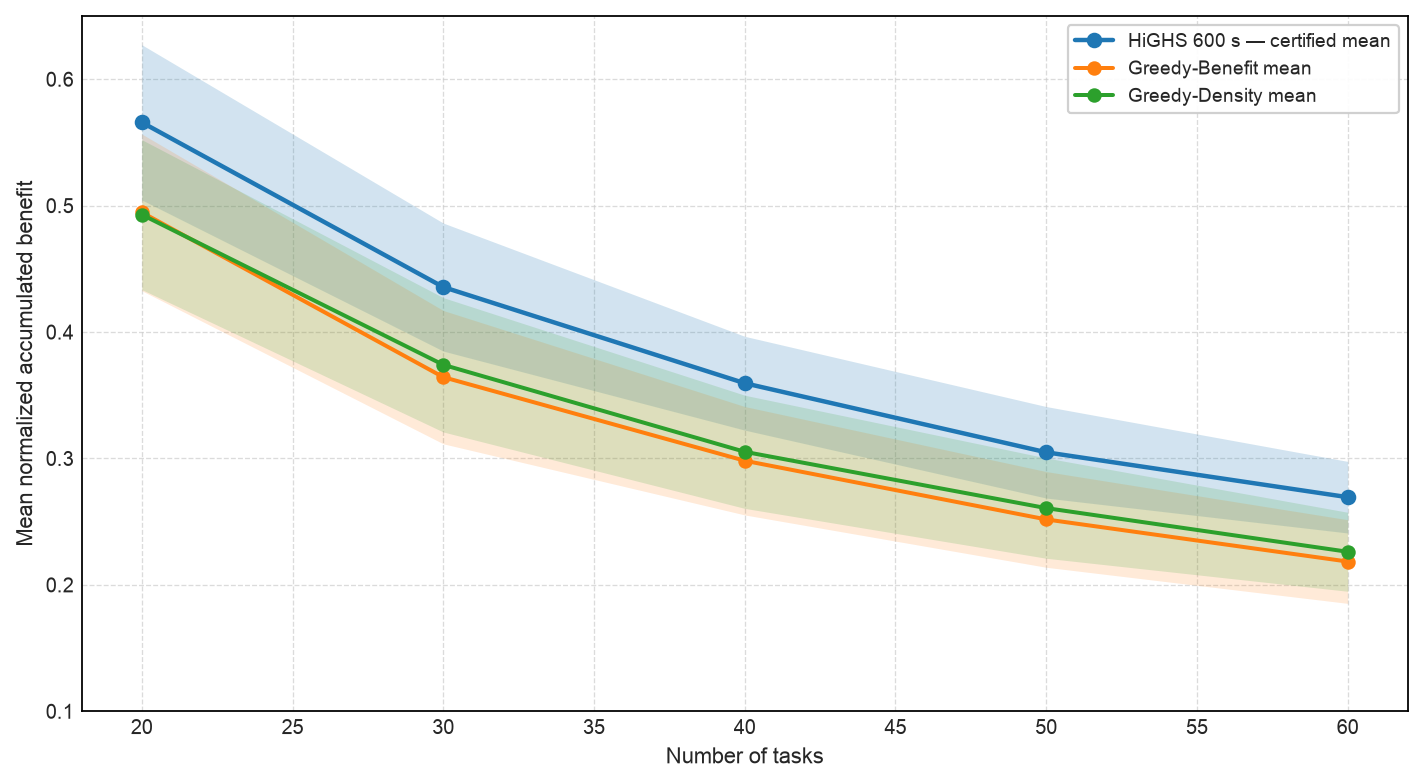

,Generated,HiGHS certified,Certification rate,Presentation
Tasks,,,,
20,30,30,1.0,Connected
30,30,30,1.0,Connected
40,30,30,1.0,Connected
50,30,30,1.0,Connected
60,30,30,1.0,Connected


In [7]:
# ============================================================
# A1 — SOLUTION QUALITY WITH COVERAGE-AWARE HIGHS RESULTS
# Same graphical logic as 20260622_Escalamiento.ipynb
# ============================================================

MIN_CERTIFICATION_RATE = 0.99


def plot_a1_coverage_aware_quality(
    df,
    save=True,
):

    # --------------------------------------------------------
    # 1. Main datasets
    # --------------------------------------------------------

    exact = df[
        df["Method"] == HIGHS_METHOD
    ].copy()

    exact_certified = exact[
        exact["Optimal Certified"]
    ].copy()

    heuristic_methods = [
        "Greedy-Benefit",
        "Greedy-Density-Operational",
    ]

    task_sizes = sorted(
        df["Tasks"].dropna().unique()
    )

    # --------------------------------------------------------
    # 2. Certification coverage
    # --------------------------------------------------------

    generated_counts = (
        exact
        .groupby("Tasks")["Scenario"]
        .nunique()
        .reindex(
            task_sizes,
            fill_value=0,
        )
    )

    certified_counts = (
        exact_certified
        .groupby("Tasks")["Scenario"]
        .nunique()
        .reindex(
            task_sizes,
            fill_value=0,
        )
    )

    certification_rate = (
        certified_counts
        / generated_counts
    )

    reliable_tasks = (
        certification_rate[
            certification_rate
            >= MIN_CERTIFICATION_RATE
        ]
        .index
        .tolist()
    )

    conditional_tasks = (
        certification_rate[
            certification_rate
            < MIN_CERTIFICATION_RATE
        ]
        .index
        .tolist()
    )

    # --------------------------------------------------------
    # 3. Summaries
    # --------------------------------------------------------

    exact_summary = (
        exact_certified
        .groupby("Tasks")[
            "Available Mission Value"
        ]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("Tasks")
    )

    heuristic_summary = (
        df[
            df["Method"].isin(
                heuristic_methods
            )
        ]
        .groupby(
            ["Tasks", "Method"],
            observed=True,
        )[
            "Available Mission Value"
        ]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(
            ["Method", "Tasks"]
        )
    )

    # --------------------------------------------------------
    # 4. Figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9.0, 5.0)
    )

    exact_color = "#1f77b4"

    # ========================================================
    # HIGHS — reliable task sizes
    # ========================================================

    exact_reliable = (
        exact_summary[
            exact_summary["Tasks"]
            .isin(reliable_tasks)
        ]
    )

    x_exact = (
        exact_reliable["Tasks"]
        .to_numpy(dtype=float)
    )

    y_exact = (
        exact_reliable["mean"]
        .to_numpy(dtype=float)
    )

    sd_exact = (
        exact_reliable["std"]
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    if len(exact_reliable) > 0:

        ax.plot(
            x_exact,
            y_exact,
            marker="o",
            color=exact_color,
            linewidth=2.0,
            markersize=6,
            label=(
                "HiGHS 600 s — "
                "certified mean"
            ),
            zorder=4,
        )

        ax.fill_between(
            x_exact,
            np.maximum(
                0.0,
                y_exact - sd_exact,
            ),
            np.minimum(
                1.0,
                y_exact + sd_exact,
            ),
            color=exact_color,
            alpha=0.20,
            linewidth=0,
            zorder=1,
        )

    # ========================================================
    # HIGHS — conditional task sizes
    # ========================================================

    exact_conditional = (
        exact_summary[
            exact_summary["Tasks"]
            .isin(conditional_tasks)
        ]
    )

    annotation_offsets = {
        40: (-75, 25),
        50: (-65, 25),
        60: (-95, 25),
    }

    conditional_legend_added = False

    for _, row in (
        exact_conditional.iterrows()
    ):

        task_count = int(
            row["Tasks"]
        )

        mean_value = float(
            row["mean"]
        )

        standard_deviation = (
            0.0
            if pd.isna(row["std"])
            else float(row["std"])
        )

        certified_n = int(
            row["count"]
        )

        generated_n = int(
            generated_counts.loc[
                task_count
            ]
        )

        label = (
            "HiGHS 600 s — "
            "conditional certified subset"
            if not conditional_legend_added
            else "_nolegend_"
        )

        ax.errorbar(
            task_count,
            mean_value,
            yerr=standard_deviation,
            fmt="o",
            linestyle="none",
            markersize=8.5,
            markerfacecolor="white",
            markeredgecolor=exact_color,
            markeredgewidth=2.0,
            ecolor=exact_color,
            elinewidth=1.5,
            capsize=4,
            label=label,
            zorder=6,
        )

        conditional_legend_added = True

        offset = annotation_offsets.get(
            task_count,
            (-70, 25),
        )

        ax.annotate(
            f"{certified_n}/{generated_n} certified",
            xy=(
                task_count,
                mean_value,
            ),
            xytext=offset,
            textcoords="offset points",
            fontsize=8.7,
            color=exact_color,
            arrowprops={
                "arrowstyle": "->",
                "color": exact_color,
                "linewidth": 0.9,
            },
            zorder=7,
        )

    # ========================================================
    # HEURISTICS — all 30 instances
    # ========================================================

    heuristic_configuration = {
        "Greedy-Benefit": {
            "color": "#ff7f0e",
            "label": "Greedy-Benefit mean",
        },
        "Greedy-Density-Operational": {
            "color": "#2ca02c",
            "label": "Greedy-Density mean",
        },
    }

    for method in heuristic_methods:

        subset = (
            heuristic_summary[
                heuristic_summary["Method"]
                == method
            ]
            .sort_values("Tasks")
        )

        x = subset["Tasks"].to_numpy(
            dtype=float
        )

        y = subset["mean"].to_numpy(
            dtype=float
        )

        standard_deviation = (
            subset["std"]
            .fillna(0.0)
            .to_numpy(dtype=float)
        )

        configuration = (
            heuristic_configuration[
                method
            ]
        )

        ax.plot(
            x,
            y,
            marker="o",
            color=configuration["color"],
            linewidth=1.8,
            markersize=5.5,
            label=configuration["label"],
            zorder=3,
        )

        ax.fill_between(
            x,
            np.maximum(
                0.0,
                y - standard_deviation,
            ),
            np.minimum(
                1.0,
                y + standard_deviation,
            ),
            color=configuration["color"],
            alpha=0.16,
            linewidth=0,
            zorder=1,
        )

    # --------------------------------------------------------
    # 5. Paper formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Number of tasks"
    )

    ax.set_ylabel(
        "Mean normalized accumulated benefit"
    )

    # Same visual range as Escalamiento.
    ax.set_xlim(18, 62)
    ax.set_ylim(0.10, 0.65)

    ax.set_xticks(
        [
            20, 25, 30, 35, 40,
            45, 50, 55, 60,
        ]
    )

    apply_paper_axis_style(ax)

    ax.legend(
        loc="upper right",
        frameon=True,
        framealpha=0.92,
    )

    # No internal title: the paper caption will provide it.
    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A1_solution_quality_coverage_aware",
        )

    plt.show()

    coverage_table = pd.DataFrame({
        "Generated": generated_counts,
        "HiGHS certified": certified_counts,
        "Certification rate":
            certification_rate,
        "Presentation": [
            (
                "Connected"
                if tasks in reliable_tasks
                else "Conditional hollow marker"
            )
            for tasks in task_sizes
        ],
    })

    return (
        heuristic_summary,
        exact_summary,
        coverage_table,
    )


(
    a1_heuristic_summary,
    a1_exact_summary,
    a1_coverage_table,
) = plot_a1_coverage_aware_quality(
    plot_metrics
)

display(a1_coverage_table)

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A2_end_to_end_computational_time.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A2_end_to_end_computational_time.pdf


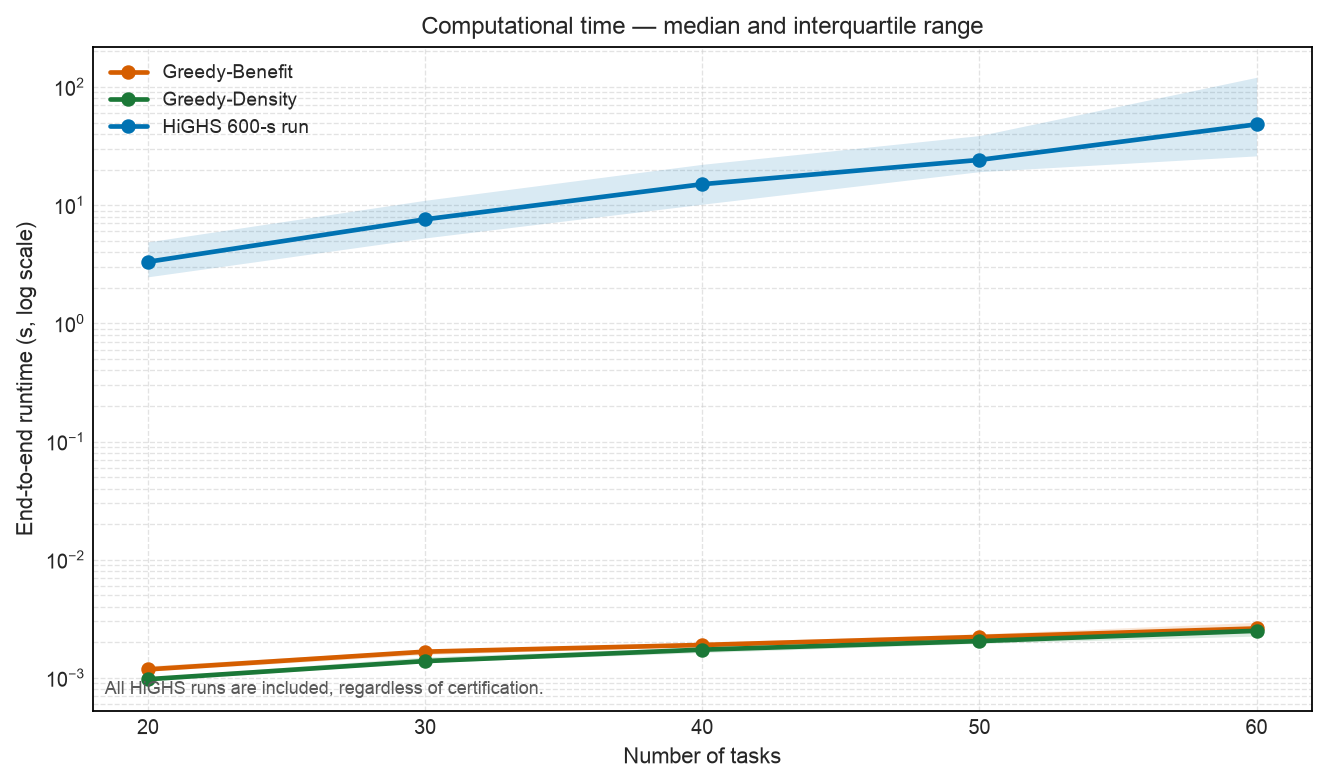

,Tasks,Method,Median,Q25,Q75,Mean,N
0,20,Greedy-Benefit,0.001180,0.001140,0.001265,0.001242,30
1,20,Greedy-Density-Operational,0.000974,0.000939,0.001011,0.001089,30
2,20,HiGHS-600s,3.317779,2.476577,4.891596,4.275329,30
3,30,Greedy-Benefit,0.001666,0.001575,0.001739,0.001915,30
4,30,Greedy-Density-Operational,0.001387,0.001350,0.001504,0.001542,30
5,30,HiGHS-600s,7.590705,5.282054,11.001962,9.523993,30
6,40,Greedy-Benefit,0.001899,0.001852,0.002002,0.001976,30
7,40,Greedy-Density-Operational,0.001733,0.001638,0.001835,0.002221,30
8,40,HiGHS-600s,15.055158,10.192831,22.170970,19.884433,30
9,50,Greedy-Benefit,0.002220,0.002148,0.002359,0.002284,30


In [8]:
# ============================================================
# A2 — END-TO-END COMPUTATIONAL TIME
# ALL RUNS, INCLUDING NON-CERTIFIED ATTEMPTS
# ============================================================

def plot_a2_computational_time(
    df,
    save=True,
):

    runtime_data = df[
        df["Method"].isin(METHOD_ORDER)
    ].copy()

    runtime_data = runtime_data[
        runtime_data["End-to-end sec"].notna()
        & runtime_data["End-to-end sec"].gt(0.0)
    ]

    runtime_summary = (
        runtime_data
        .groupby(
            ["Tasks", "Method"],
            observed=True,
        )
        .agg(
            Median=(
                "End-to-end sec",
                "median",
            ),
            Q25=(
                "End-to-end sec",
                lambda values:
                    values.quantile(0.25),
            ),
            Q75=(
                "End-to-end sec",
                lambda values:
                    values.quantile(0.75),
            ),
            Mean=(
                "End-to-end sec",
                "mean",
            ),
            N=(
                "Scenario",
                "nunique",
            ),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(
        figsize=(8.4, 5.0)
    )

    for method in METHOD_ORDER:

        subset = (
            runtime_summary[
                runtime_summary["Method"] == method
            ]
            .set_index("Tasks")
            .reindex(TASK_SIZES)
        )

        median = subset["Median"].to_numpy(
            dtype=float
        )

        q25 = subset["Q25"].to_numpy(
            dtype=float
        )

        q75 = subset["Q75"].to_numpy(
            dtype=float
        )

        label = (
            "HiGHS 600-s run"
            if method == HIGHS_METHOD
            else METHOD_LABELS[method]
        )

        ax.plot(
            TASK_SIZES,
            median,
            marker="o",
            markersize=5.5,
            linewidth=2.1,
            color=METHOD_COLORS[method],
            label=label,
        )

        ax.fill_between(
            TASK_SIZES,
            q25,
            q75,
            color=METHOD_COLORS[method],
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xlabel(
        "Number of tasks"
    )

    ax.set_ylabel(
        "End-to-end runtime (s, log scale)"
    )

    ax.set_title(
        "Computational time — median and interquartile range"
    )

    ax.set_xticks(TASK_SIZES)
    ax.set_yscale("log")

    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.55,
    )

    ax.legend(
        frameon=False,
    )

    ax.text(
        0.01,
        0.02,
        "All HiGHS runs are included, regardless of certification.",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        color="0.35",
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A2_end_to_end_computational_time.pdf",
        )

    plt.show()

    return runtime_summary


a2_runtime_summary = (
    plot_a2_computational_time(
        plot_metrics
    )
)

display(a2_runtime_summary)

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A3_certification_by_tasks_and_budget.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A3_certification_by_tasks_and_budget.pdf


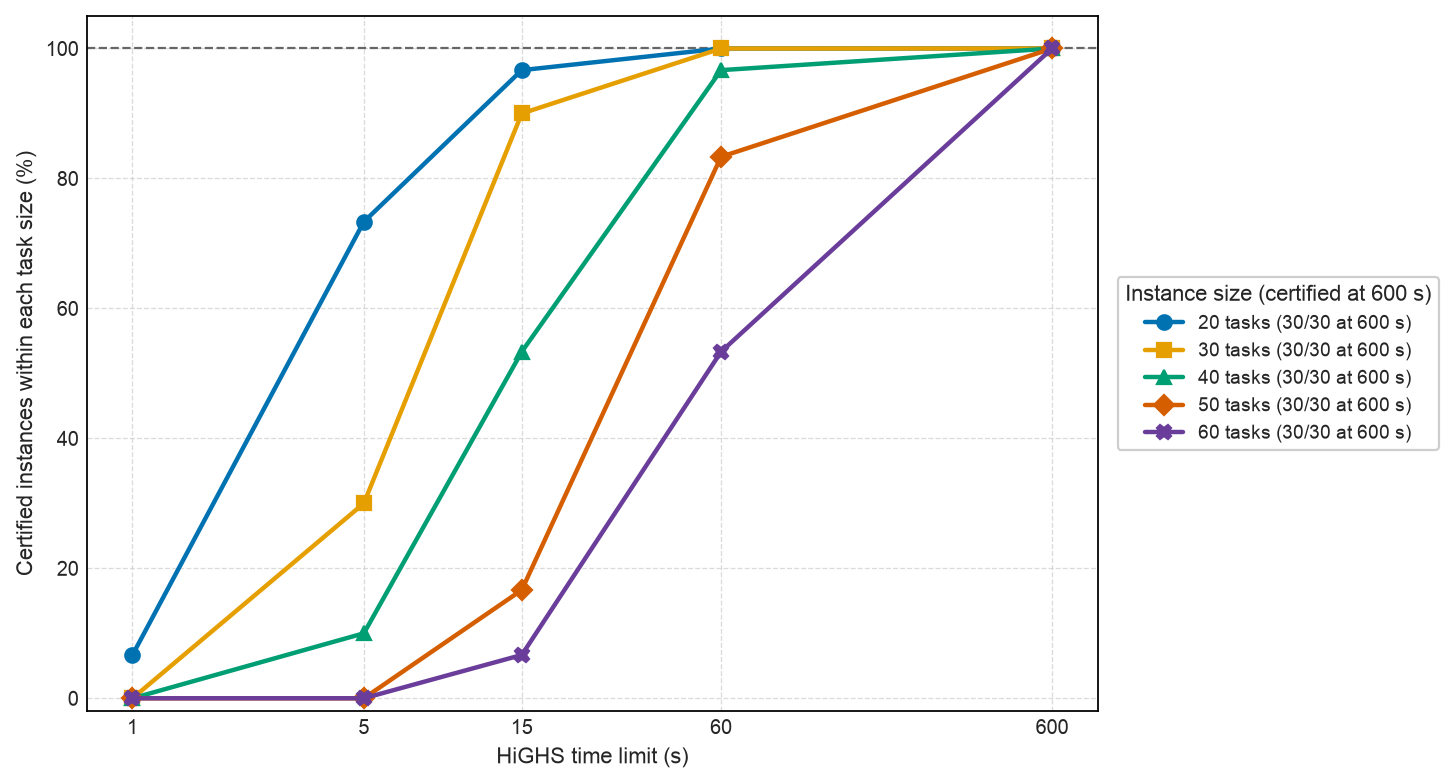

,Tasks,Budget sec,Instances,Certified,Certification Rate,Certification Percent
0,20,1.0,30,2,0.066667,6.666667
1,20,5.0,30,22,0.733333,73.333333
2,20,15.0,30,29,0.966667,96.666667
3,20,60.0,30,30,1.000000,100.000000
4,20,600.0,30,30,1.000000,100.000000
5,30,1.0,30,0,0.000000,0.000000
6,30,5.0,30,9,0.300000,30.000000
7,30,15.0,30,27,0.900000,90.000000
8,30,60.0,30,30,1.000000,100.000000
9,30,600.0,30,30,1.000000,100.000000


In [9]:
# ============================================================
# A3 — OPTIMALITY CERTIFICATION BY TASK SIZE AND TIME BUDGET
# Each curve represents 30 instances of the same task size
# ============================================================

def plot_a3_certification_by_tasks_and_budget(
    df,
    save=True,
):

    # --------------------------------------------------------
    # 1. HiGHS results
    # --------------------------------------------------------

    highs = df[
        df["Method"].str.startswith(
            "HiGHS",
            na=False,
        )
    ].copy()

    highs = highs[
        highs["Budget sec"].notna()
    ].copy()

    highs["Optimal Certified"] = (
        highs["Optimal Certified"]
        .fillna(False)
        .astype(bool)
    )

    # --------------------------------------------------------
    # 2. Certification within each task size
    # --------------------------------------------------------

    certification_summary = (
        highs
        .groupby(
            ["Tasks", "Budget sec"],
            observed=True,
        )
        .agg(
            Instances=(
                "Scenario",
                "nunique",
            ),
            Certified=(
                "Optimal Certified",
                "sum",
            ),
        )
        .reset_index()
        .sort_values(
            ["Tasks", "Budget sec"]
        )
    )

    certification_summary[
        "Certification Rate"
    ] = (
        certification_summary["Certified"]
        / certification_summary["Instances"]
    )

    certification_summary[
        "Certification Percent"
    ] = (
        100.0
        * certification_summary[
            "Certification Rate"
        ]
    )

    # Every task-size/budget combination must contain 30 seeds.
    if not (
        certification_summary["Instances"]
        .eq(30)
        .all()
    ):
        invalid = certification_summary[
            ~certification_summary[
                "Instances"
            ].eq(30)
        ]

        display(invalid)

        raise RuntimeError(
            "Every task-size/budget combination "
            "must contain exactly 30 instances."
        )

    # --------------------------------------------------------
    # 3. Final certification counts for the legend
    # --------------------------------------------------------

    maximum_budget = float(
        certification_summary[
            "Budget sec"
        ].max()
    )

    final_certification = (
        certification_summary[
            certification_summary[
                "Budget sec"
            ].eq(maximum_budget)
        ]
        .set_index("Tasks")
    )

    # Different markers make the curves identifiable
    # even if printed without color.
    task_markers = {
        20: "o",
        30: "s",
        40: "^",
        50: "D",
        60: "X",
    }

    # --------------------------------------------------------
    # 4. Figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9.2, 5.0)
    )

    for tasks in TASK_SIZES:

        subset = (
            certification_summary[
                certification_summary[
                    "Tasks"
                ].eq(tasks)
            ]
            .set_index("Budget sec")
            .reindex(BUDGETS)
            .reset_index()
        )

        certified_at_600 = int(
            final_certification.loc[
                tasks,
                "Certified",
            ]
        )

        total_at_600 = int(
            final_certification.loc[
                tasks,
                "Instances",
            ]
        )

        ax.plot(
            subset["Budget sec"],
            subset[
                "Certification Percent"
            ],
            marker=task_markers[tasks],
            markersize=6.5,
            linewidth=2.0,
            color=TASK_COLORS[tasks],
            label=(
                f"{int(tasks)} tasks "
                f"({certified_at_600}/"
                f"{total_at_600} at 600 s)"
            ),
            zorder=3,
        )

    # --------------------------------------------------------
    # 5. Paper formatting
    # --------------------------------------------------------

    ax.set_xscale("log")

    ax.set_xticks(
        BUDGETS,
        [
            f"{budget:g}"
            for budget in BUDGETS
        ],
    )

    ax.set_yticks(
        np.arange(
            0.0,
            101.0,
            20.0,
        )
    )

    ax.set_xlabel(
        "HiGHS time limit (s)"
    )

    ax.set_ylabel(
        "Certified instances within each task size (%)"
    )

    ax.set_ylim(
        -2.0,
        105.0,
    )

    # Complete-certification reference.
    ax.axhline(
        100.0,
        color="0.40",
        linestyle="--",
        linewidth=1.0,
        zorder=1,
    )

    apply_paper_axis_style(
        ax,
        grid_axis="both",
    )

    # External legend prevents overlap between T20 and T30
    # at 100% certification.
    ax.legend(
        title=(
            "Instance size "
            "(certified at 600 s)"
        ),
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        framealpha=0.95,
    )

    # Paper caption provides the title.
    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A3_certification_by_tasks_and_budget",
        )

    plt.show()

    return certification_summary


a3_certification_summary = (
    plot_a3_certification_by_tasks_and_budget(
        plot_metrics
    )
)

display(a3_certification_summary)

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A5_paired_mission_value_advantages.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A5_paired_mission_value_advantages.pdf


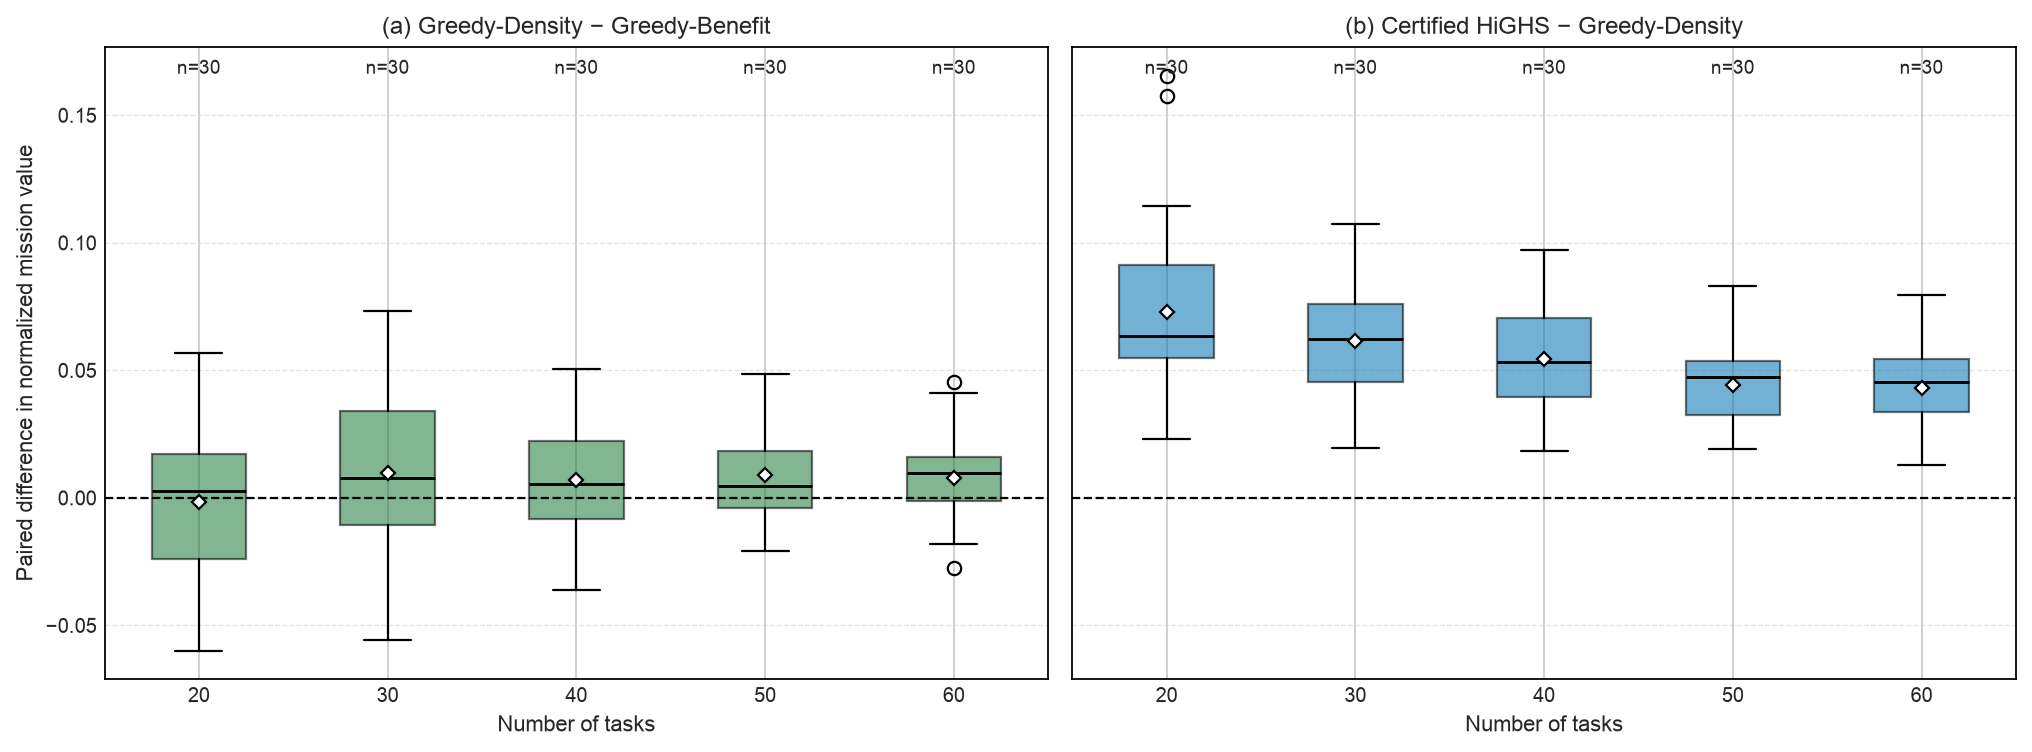

,mean,std,count
Tasks,,,
20,-0.001797,0.028881,30
30,0.009761,0.029060,30
40,0.007062,0.022490,30
50,0.008940,0.017947,30
60,0.007738,0.015584,30


,mean,std,count
Tasks,,,
20,0.072999,0.033518,30
30,0.061497,0.022167,30
40,0.054251,0.019664,30
50,0.044156,0.016229,30
60,0.043185,0.015697,30


In [10]:
# ============================================================
# A5 — PAIRED MISSION-VALUE DIFFERENCES
# (a) Density versus Benefit
# (b) Certified HiGHS versus Density
# ============================================================

def plot_a5_paired_advantages(
    df,
    save=True,
):

    # --------------------------------------------------------
    # 1. Density versus Benefit — all scenarios
    # --------------------------------------------------------

    heuristic_pivot = (
        df[
            df["Method"].isin(
                [
                    "Greedy-Benefit",
                    "Greedy-Density-Operational",
                ]
            )
        ]
        .pivot(
            index=["Scenario", "Tasks"],
            columns="Method",
            values="Available Mission Value",
        )
    )

    heuristic_difference = (
        heuristic_pivot[
            "Greedy-Density-Operational"
        ]
        - heuristic_pivot[
            "Greedy-Benefit"
        ]
    ).dropna()

    heuristic_difference = (
        heuristic_difference
        .rename("Difference")
        .reset_index()
    )

    # --------------------------------------------------------
    # 2. Certified HiGHS versus Density
    # --------------------------------------------------------

    certified_exact = (
        df[
            (df["Method"] == HIGHS_METHOD)
            & df["Optimal Certified"]
        ][
            [
                "Scenario",
                "Tasks",
                "Available Mission Value",
            ]
        ]
        .rename(
            columns={
                "Available Mission Value":
                    "Exact Value"
            }
        )
    )

    density = (
        df[
            df["Method"]
            == "Greedy-Density-Operational"
        ][
            [
                "Scenario",
                "Tasks",
                "Available Mission Value",
            ]
        ]
        .rename(
            columns={
                "Available Mission Value":
                    "Density Value"
            }
        )
    )

    exact_difference = (
        certified_exact
        .merge(
            density,
            on=["Scenario", "Tasks"],
            how="inner",
            validate="one_to_one",
        )
    )

    exact_difference["Difference"] = (
        exact_difference["Exact Value"]
        - exact_difference["Density Value"]
    )

    # --------------------------------------------------------
    # 3. Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12.8, 4.8),
        sharey=True,
    )

    comparisons = [
        (
            axes[0],
            heuristic_difference,
            "(a) Greedy-Density − Greedy-Benefit",
            "#1B7837",
        ),
        (
            axes[1],
            exact_difference,
            "(b) Certified HiGHS − Greedy-Density",
            "#0072B2",
        ),
    ]

    for axis, data, title, color in comparisons:

        groups = [
            data.loc[
                data["Tasks"] == tasks,
                "Difference",
            ]
            for tasks in TASK_SIZES
        ]

        boxplot = axis.boxplot(
            groups,
            tick_labels=[
                str(int(tasks))
                for tasks in TASK_SIZES
            ],
            patch_artist=True,
            showmeans=True,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 4.5,
            },
            medianprops={
                "color": "black",
                "linewidth": 1.3,
            },
        )

        for patch in boxplot["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.55)

        for position, tasks in enumerate(
            TASK_SIZES,
            start=1,
        ):
            n = int(
                (data["Tasks"] == tasks).sum()
            )

            axis.text(
                position,
                0.98,
                f"n={n}",
                transform=axis.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=8.5,
            )

        axis.axhline(
            0.0,
            color="black",
            linewidth=1.0,
            linestyle="--",
        )

        axis.set_xlabel(
            "Number of tasks"
        )

        axis.set_title(title)

        axis.grid(
            axis="y",
            linestyle="--",
            linewidth=0.6,
            alpha=0.55,
        )

        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(0.8)

    axes[0].set_ylabel(
        "Paired difference in normalized mission value"
    )

    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A5_paired_mission_value_advantages.pdf",
        )

    plt.show()

    return (
        heuristic_difference,
        exact_difference,
    )


(
    a5_heuristic_difference,
    a5_exact_difference,
) = plot_a5_paired_advantages(
    plot_metrics
)

display(
    a5_heuristic_difference
    .groupby("Tasks")["Difference"]
    .agg(["mean", "std", "count"])
)

display(
    a5_exact_difference
    .groupby("Tasks")["Difference"]
    .agg(["mean", "std", "count"])
)

In [11]:
# ============================================================
# REPRESENTATIVE CERTIFIED SCENARIO FOR A6 AND A7
# ============================================================

TARGET_TASKS = 20

representative_candidates = (
    plot_metrics[
        (plot_metrics["Method"] == HIGHS_METHOD)
        & plot_metrics["Optimal Certified"]
        & plot_metrics["Has Positive Plan"]
        & plot_metrics["Tasks"].eq(
            TARGET_TASKS
        )
    ]
    .copy()
)

if representative_candidates.empty:
    raise RuntimeError(
        "No certified positive scenario is available "
        f"for {TARGET_TASKS} tasks."
    )

median_variables = (
    representative_candidates["Variables"]
    .median()
)

representative_candidates[
    "Distance from Median"
] = (
    representative_candidates["Variables"]
    - median_variables
).abs()

representative_row = (
    representative_candidates
    .sort_values(
        [
            "Distance from Median",
            "Seed",
        ]
    )
    .iloc[0]
)

representative_scenario_id = str(
    representative_row["Scenario"]
)

representative_scenario = create_scenario(
    n_tasks=int(
        representative_row["Tasks"]
    ),
    seed=int(
        representative_row["Seed"]
    ),
    scenario_id=representative_scenario_id,
)

representative_result = {
    "scenario": representative_scenario,
    "method_logs": {
        method: (
            df_logs_scaling[
                (
                    df_logs_scaling["Scenario"]
                    == representative_scenario_id
                )
                & (
                    df_logs_scaling["Method"]
                    == method
                )
            ]
            .copy()
            .reset_index(drop=True)
        )
        for method in METHOD_ORDER
    },
}

print(
    "Representative certified scenario:",
    representative_scenario_id,
)

display(
    representative_row[
        [
            "Scenario",
            "Seed",
            "Tasks",
            "Variables",
            "Constraints",
            "Nonzeros",
            "Normalized Mission Value",
            "Optimal Certified",
        ]
    ]
)

Representative certified scenario: A4x4_T20_S23


Scenario                    A4x4_T20_S23
Seed                                  23
Tasks                                 20
Variables                        14450.0
Constraints                       6186.0
Nonzeros                         37188.0
Normalized Mission Value        0.528621
Optimal Certified                   True
Name: 160, dtype: object

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A6_representative_certified_route_maps.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A6_representative_certified_route_maps.pdf


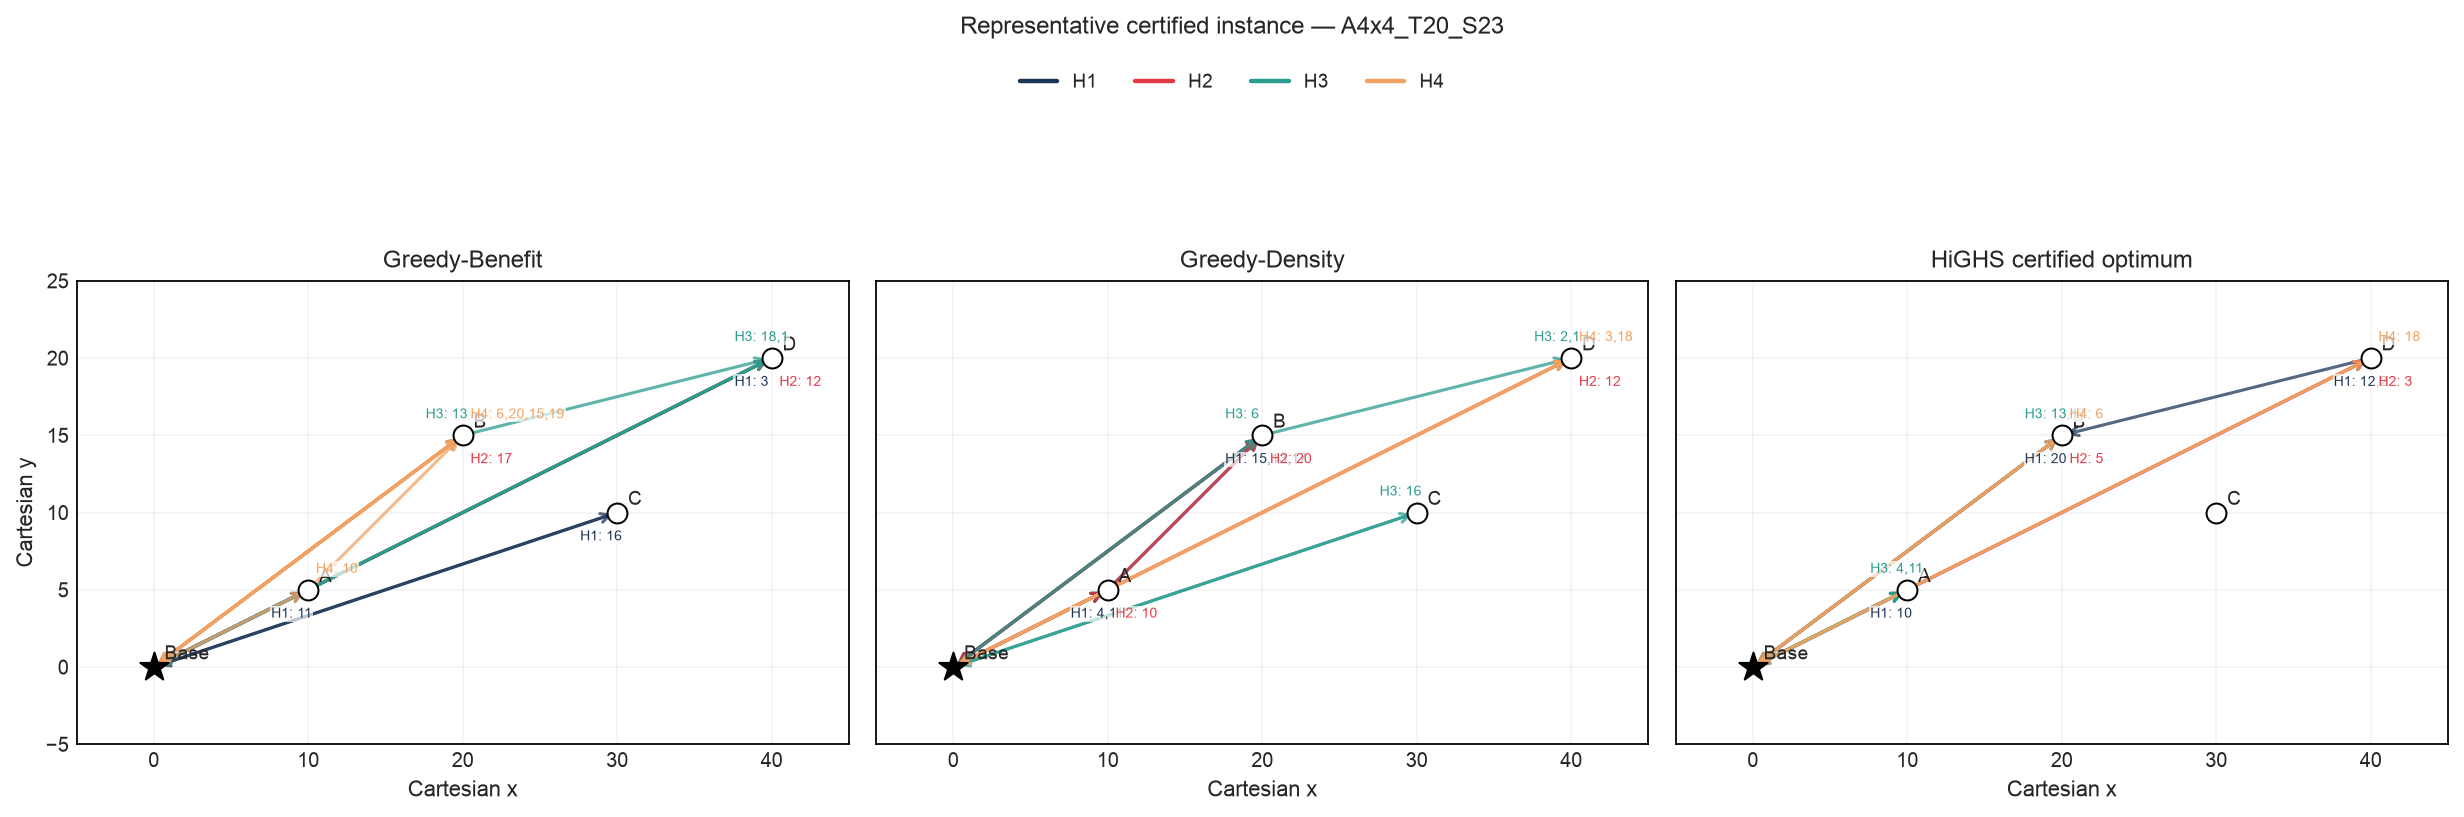

In [12]:
# ============================================================
# A6 — ROUTE MAPS FOR A REPRESENTATIVE CERTIFIED INSTANCE
# ============================================================

HELO_COLORS = {
    1: "#1D3557",
    2: "#E63946",
    3: "#2A9D8F",
    4: "#F4A261",
}


def plot_a6_route_maps(
    result,
    save=True,
):

    scenario = result["scenario"]

    methods = [
        "Greedy-Benefit",
        "Greedy-Density-Operational",
        HIGHS_METHOD,
    ]

    figure_labels = {
        "Greedy-Benefit":
            "Greedy-Benefit",

        "Greedy-Density-Operational":
            "Greedy-Density",

        HIGHS_METHOD:
            "HiGHS certified optimum",
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15.5, 5.1),
        sharex=True,
        sharey=True,
    )

    x_values = [
        coordinates[0]
        for coordinates
        in scenario["nodes"].values()
    ]

    y_values = [
        coordinates[1]
        for coordinates
        in scenario["nodes"].values()
    ]

    for axis, method in zip(
        axes,
        methods,
    ):

        logs = result[
            "method_logs"
        ].get(
            method,
            pd.DataFrame(),
        )

        task_labels = defaultdict(list)

        # Nodes
        for node, (x, y) in (
            scenario["nodes"].items()
        ):

            marker = (
                "*"
                if node == "Base"
                else "o"
            )

            size = (
                180
                if node == "Base"
                else 80
            )

            axis.scatter(
                x,
                y,
                marker=marker,
                s=size,
                color=(
                    "black"
                    if node == "Base"
                    else "white"
                ),
                edgecolor="black",
                linewidth=0.9,
                zorder=5,
            )

            axis.text(
                x + 0.7,
                y + 0.5,
                node,
                fontsize=8.5,
            )

        # Routes
        if (
            logs is not None
            and not logs.empty
        ):

            for helo_id, helo_logs in (
                logs.groupby("Helo ID")
            ):

                helo = int(helo_id)

                helo_logs = (
                    helo_logs
                    .sort_values(
                        "Completion Time"
                    )
                )

                for _, event in (
                    helo_logs.iterrows()
                ):

                    start_node = event[
                        "Start Node"
                    ]

                    end_node = event["Node"]

                    x0, y0 = scenario[
                        "nodes"
                    ][start_node]

                    x1, y1 = scenario[
                        "nodes"
                    ][end_node]

                    axis.annotate(
                        "",
                        xy=(x1, y1),
                        xytext=(x0, y0),
                        arrowprops={
                            "arrowstyle": "->",
                            "color": HELO_COLORS[helo],
                            "linewidth": 1.4,
                            "alpha": 0.75,
                        },
                        zorder=2,
                    )

                    if (
                        event["Status"]
                        == "Task Executed"
                    ):
                        task_labels[
                            (helo, end_node)
                        ].append(
                            int(event["Task ID"])
                        )

        label_offsets = {
            1: (-2.4, -1.8),
            2: (0.5, -1.8),
            3: (-2.4, 1.1),
            4: (0.5, 1.1),
        }

        for (
            helo,
            node,
        ), task_ids in task_labels.items():

            x, y = scenario["nodes"][node]
            dx, dy = label_offsets[helo]

            sequence = ",".join(
                str(task_id)
                for task_id in task_ids
            )

            axis.text(
                x + dx,
                y + dy,
                f"H{helo}: {sequence}",
                fontsize=6.4,
                color=HELO_COLORS[helo],
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.70,
                    "pad": 0.5,
                },
                zorder=6,
            )

        axis.set_title(
            figure_labels[method]
        )

        axis.set_xlabel(
            "Cartesian x"
        )

        axis.set_aspect(
            "equal",
            adjustable="box",
        )

        axis.set_xlim(
            min(x_values) - 5,
            max(x_values) + 5,
        )

        axis.set_ylim(
            min(y_values) - 5,
            max(y_values) + 5,
        )

        axis.grid(
            alpha=0.20,
        )

        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(0.8)

    axes[0].set_ylabel(
        "Cartesian y"
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=HELO_COLORS[helo],
            linewidth=2,
            label=f"H{helo}",
        )
        for helo in sorted(HELO_COLORS)
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.03),
    )

    fig.suptitle(
        "Representative certified instance — "
        f"{scenario['scenario_id']}",
        y=1.08,
        fontsize=11,
    )

    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A6_representative_certified_route_maps.pdf",
        )

    plt.show()


plot_a6_route_maps(
    representative_result
)

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A7_gantt_and_cumulative_value.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A7_gantt_and_cumulative_value.pdf


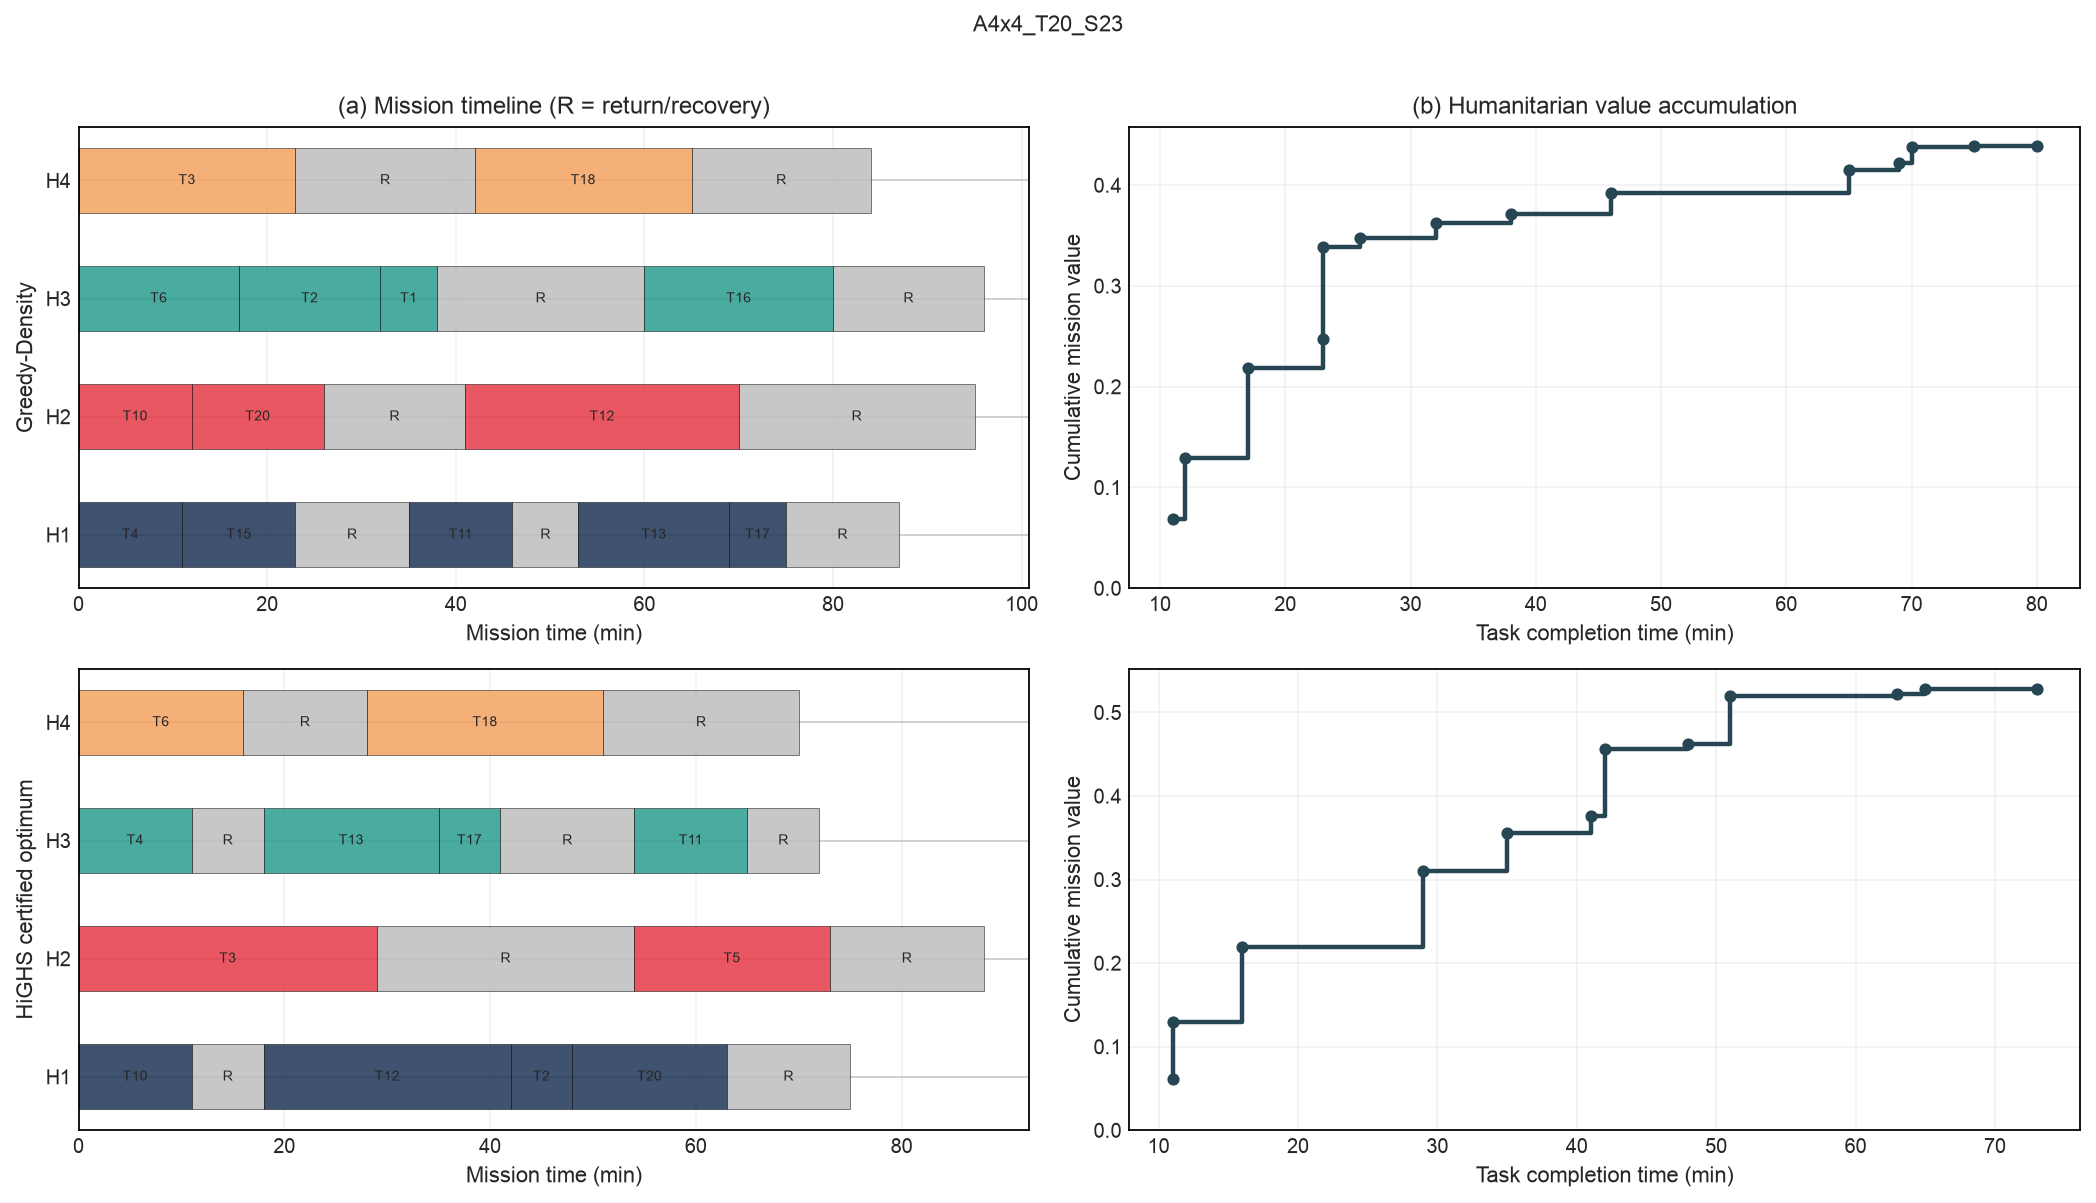

In [13]:
# ============================================================
# A7 — GANTT AND CUMULATIVE MISSION VALUE
# GREEDY-DENSITY VERSUS CERTIFIED HIGHS
# ============================================================

def plot_a7_gantt_and_value(
    result,
    save=True,
):

    methods = [
        "Greedy-Density-Operational",
        HIGHS_METHOD,
    ]

    method_labels = {
        "Greedy-Density-Operational":
            "Greedy-Density",

        HIGHS_METHOD:
            "HiGHS certified optimum",
    }

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.2, 7.4),
        squeeze=False,
    )

    for row_index, method in enumerate(
        methods
    ):

        logs = result[
            "method_logs"
        ].get(
            method,
            pd.DataFrame(),
        )

        gantt_ax = axes[row_index, 0]
        value_ax = axes[row_index, 1]

        if logs is None or logs.empty:

            gantt_ax.text(
                0.5,
                0.5,
                "No operational plan",
                transform=gantt_ax.transAxes,
                ha="center",
                va="center",
            )

            value_ax.text(
                0.5,
                0.5,
                "No operational plan",
                transform=value_ax.transAxes,
                ha="center",
                va="center",
            )

            continue

        ordered_logs = logs.sort_values(
            "Start Time"
        )

        for _, event in (
            ordered_logs.iterrows()
        ):

            helo = int(event["Helo ID"])

            duration = (
                float(event["Completion Time"])
                - float(event["Start Time"])
            )

            is_task = (
                event["Status"]
                == "Task Executed"
            )

            color = (
                HELO_COLORS[helo]
                if is_task
                else "#BDBDBD"
            )

            gantt_ax.barh(
                helo,
                duration,
                left=float(
                    event["Start Time"]
                ),
                height=0.55,
                color=color,
                alpha=0.85,
                edgecolor="black",
                linewidth=0.25,
            )

            label = (
                f"T{int(event['Task ID'])}"
                if is_task
                else "R"
            )

            gantt_ax.text(
                float(event["Start Time"])
                + duration / 2.0,
                helo,
                label,
                ha="center",
                va="center",
                fontsize=6.5,
            )

        task_logs = (
            logs[
                logs["Status"]
                == "Task Executed"
            ]
            .sort_values(
                "Completion Time"
            )
            .copy()
        )

        task_logs[
            "Cumulative Mission Value"
        ] = (
            task_logs["Benefit"]
            .astype(float)
            .cumsum()
        )

        if not task_logs.empty:

            value_ax.step(
                task_logs["Completion Time"],
                task_logs[
                    "Cumulative Mission Value"
                ],
                where="post",
                color="#264653",
                linewidth=2.0,
            )

            value_ax.scatter(
                task_logs["Completion Time"],
                task_logs[
                    "Cumulative Mission Value"
                ],
                color="#264653",
                s=20,
                zorder=3,
            )

        helo_ids = sorted(
            int(
                helo[1:]
                if isinstance(helo, str)
                and helo.startswith("H")
                else helo
            )
            for helo in result[
                "scenario"
            ]["helicopters"]
        )

        gantt_ax.set_yticks(
            helo_ids,
            [f"H{helo}" for helo in helo_ids],
        )

        gantt_ax.set_ylabel(
            method_labels[method]
        )

        gantt_ax.set_xlabel(
            "Mission time (min)"
        )

        gantt_ax.grid(
            axis="x",
            alpha=0.25,
        )

        value_ax.set_xlabel(
            "Task completion time (min)"
        )

        value_ax.set_ylabel(
            "Cumulative mission value"
        )

        value_ax.set_ylim(
            bottom=0.0
        )

        value_ax.grid(
            alpha=0.25,
        )

        for axis in [
            gantt_ax,
            value_ax,
        ]:
            for spine in axis.spines.values():
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(0.8)

    axes[0, 0].set_title(
        "(a) Mission timeline "
        "(R = return/recovery)"
    )

    axes[0, 1].set_title(
        "(b) Humanitarian value accumulation"
    )

    fig.suptitle(
        representative_scenario_id,
        y=1.01,
        fontsize=10,
    )

    fig.tight_layout()

    if save:
        save_paper_figure(
            fig,
            "A7_gantt_and_cumulative_value.pdf",
        )

    plt.show()


plot_a7_gantt_and_value(
    representative_result
)

PNG saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A8_highs_computational_effort_and_state_arc_size.png
PDF saved at: ttap_experiment_A_4x4_impact_anytime_traced/figures/A4x4_paper_20260808_112401-0400_recovered/A8_highs_computational_effort_and_state_arc_size.pdf


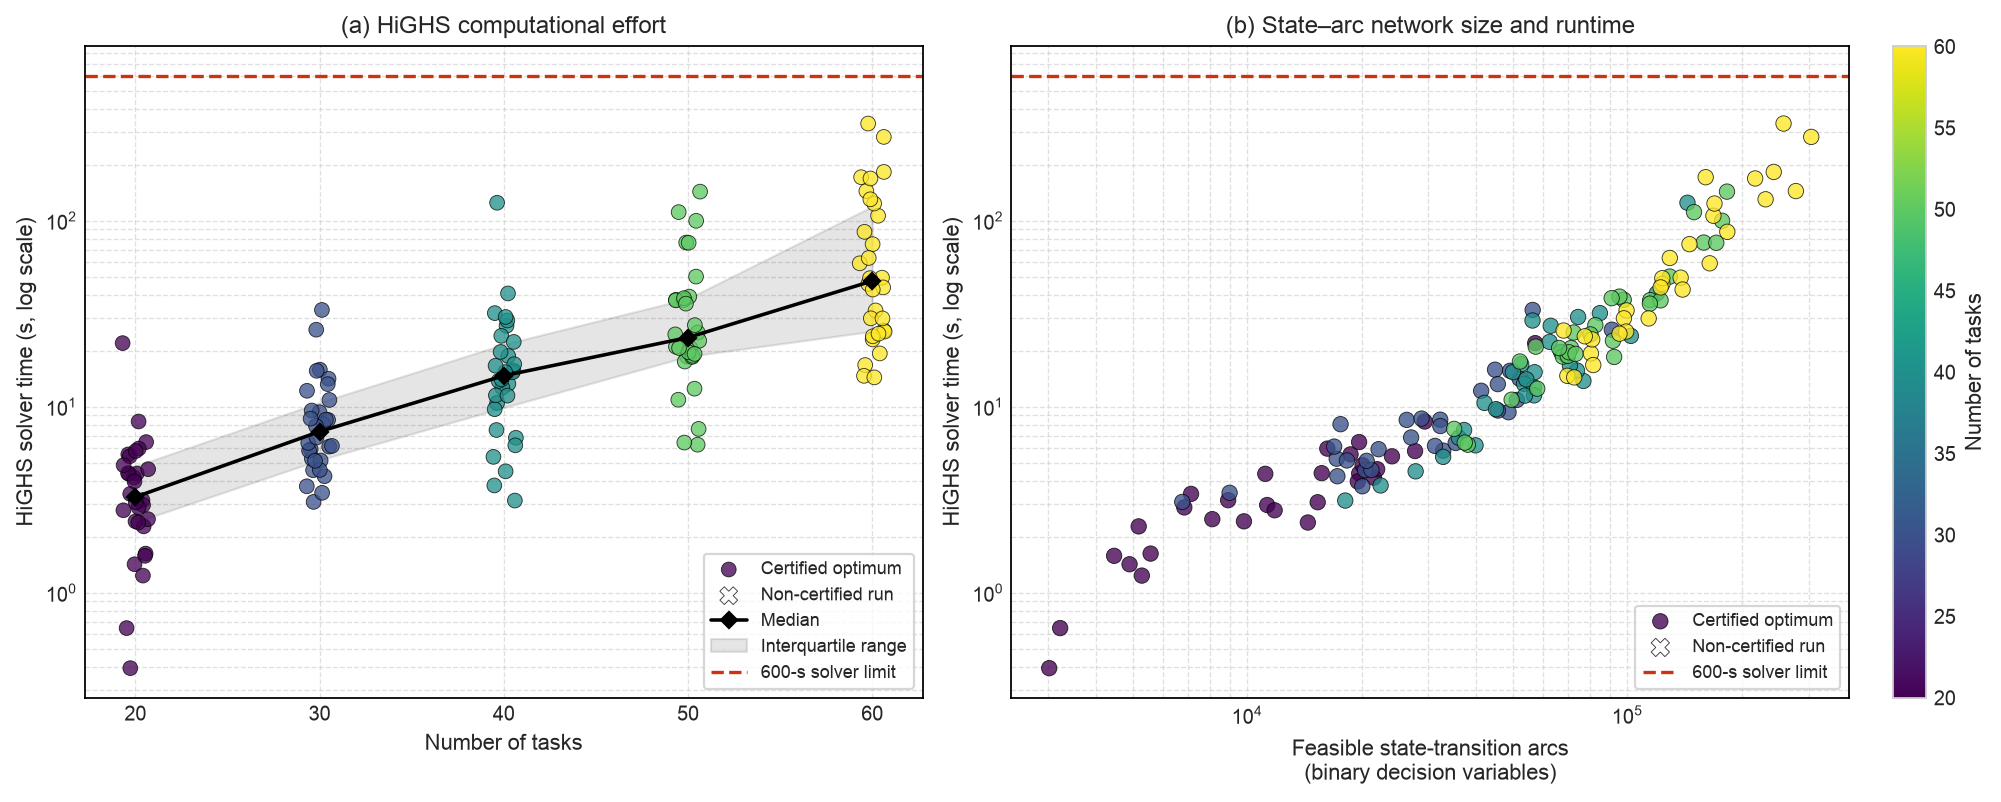

,Median,Q25,Q75
Tasks,,,
20,3.277509,2.398508,4.799136
30,7.366915,5.178754,10.559343
40,14.701148,9.912863,21.697303
50,23.594266,18.675933,38.208771
60,47.477792,25.480093,119.526376


In [14]:
# ============================================================
# A8 — HIGHS COMPUTATIONAL EFFORT
# (a) Runtime by number of tasks
# (b) State-transition arcs versus runtime
# ============================================================

def plot_a8_computational_effort(
    df,
    save=True,
):

    solver_limit = 600.0
    runtime_column = "Solver Time sec"

    exact = df[
        df["Method"] == HIGHS_METHOD
    ].copy()

    exact = exact.dropna(
        subset=[
            "Tasks",
            "Variables",
            runtime_column,
        ]
    )

    exact = exact[
        exact[runtime_column] > 0.0
    ]

    if exact.empty:
        raise RuntimeError(
            "No HiGHS-600s observations are available."
        )

    task_sizes = sorted(
        exact["Tasks"].unique()
    )

    normalization = plt.Normalize(
        min(task_sizes),
        max(task_sizes),
    )

    color_map = plt.get_cmap(
        "viridis"
    )

    random_generator = (
        np.random.default_rng(7)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12.4, 4.9),
        constrained_layout=True,
    )

    effort_ax = axes[0]
    structure_ax = axes[1]

    # --------------------------------------------------------
    # Panel (a)
    # --------------------------------------------------------

    for certified, marker, label in [
        (
            True,
            "o",
            "Certified optimum",
        ),
        (
            False,
            "X",
            "Non-certified run",
        ),
    ]:

        subset = exact[
            exact["Optimal Certified"]
            == certified
        ]

        jitter = random_generator.uniform(
            -0.70,
            0.70,
            size=len(subset),
        )

        effort_ax.scatter(
            subset["Tasks"] + jitter,
            subset[runtime_column],
            c=subset["Tasks"],
            cmap=color_map,
            norm=normalization,
            marker=marker,
            s=(
                44
                if certified
                else 64
            ),
            alpha=0.76,
            edgecolor="black",
            linewidth=0.4,
            label=label,
            zorder=3,
        )

    runtime_summary = (
        exact
        .groupby("Tasks")
        [runtime_column]
        .agg(
            Median="median",
            Q25=lambda values:
                values.quantile(0.25),
            Q75=lambda values:
                values.quantile(0.75),
        )
        .reindex(task_sizes)
    )

    effort_ax.plot(
        task_sizes,
        runtime_summary["Median"],
        color="black",
        marker="D",
        markersize=5,
        linewidth=1.6,
        label="Median",
        zorder=4,
    )

    effort_ax.fill_between(
        task_sizes,
        runtime_summary["Q25"],
        runtime_summary["Q75"],
        color="black",
        alpha=0.10,
        label="Interquartile range",
    )

    effort_ax.axhline(
        solver_limit,
        color="#CC3311",
        linestyle="--",
        linewidth=1.5,
        label="600-s solver limit",
    )

    effort_ax.set_yscale("log")

    effort_ax.set_xlabel(
        "Number of tasks"
    )

    effort_ax.set_ylabel(
        "HiGHS solver time (s, log scale)"
    )

    effort_ax.set_title(
        "(a) HiGHS computational effort"
    )

    effort_ax.set_xticks(task_sizes)

    effort_ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.60,
    )

    effort_ax.legend(
        frameon=True,
        fontsize=8,
        loc="lower right",
    )

    # --------------------------------------------------------
    # Panel (b)
    # --------------------------------------------------------

    for certified, marker, label in [
        (
            True,
            "o",
            "Certified optimum",
        ),
        (
            False,
            "X",
            "Non-certified run",
        ),
    ]:

        subset = exact[
            exact["Optimal Certified"]
            == certified
        ]

        structure_ax.scatter(
            subset["Variables"],
            subset[runtime_column],
            c=subset["Tasks"],
            cmap=color_map,
            norm=normalization,
            marker=marker,
            s=(
                48
                if certified
                else 68
            ),
            alpha=0.78,
            edgecolor="black",
            linewidth=0.4,
            label=label,
            zorder=3,
        )

    structure_ax.axhline(
        solver_limit,
        color="#CC3311",
        linestyle="--",
        linewidth=1.5,
        label="600-s solver limit",
    )

    structure_ax.set_xscale("log")
    structure_ax.set_yscale("log")

    structure_ax.set_xlabel(
        "Feasible state-transition arcs\n"
        "(binary decision variables)"
    )

    structure_ax.set_ylabel(
        "HiGHS solver time (s, log scale)"
    )

    structure_ax.set_title(
        "(b) State–arc network size and runtime"
    )

    structure_ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.60,
    )

    structure_ax.legend(
        frameon=True,
        fontsize=8,
        loc="lower right",
    )

    for axis in axes:
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(0.8)

    color_mapper = plt.cm.ScalarMappable(
        norm=normalization,
        cmap=color_map,
    )

    color_mapper.set_array([])

    colorbar = fig.colorbar(
        color_mapper,
        ax=axes,
        fraction=0.026,
        pad=0.025,
    )

    colorbar.set_label(
        "Number of tasks"
    )

    if save:
        save_paper_figure(
            fig,
            "A8_highs_computational_effort_and_state_arc_size.pdf",
        )

    plt.show()

    return runtime_summary


a8_runtime_summary = (
    plot_a8_computational_effort(
        plot_metrics
    )
)

display(a8_runtime_summary)